# 02 — Business Join & Hotel Filter

**Goal:** Join `review.json` with `business.json` to filter down to hotel reviews only.

**Why hotels?**
- Hotel reviews are naturally multi-aspect: a single review covers room quality, staff, location, breakfast, cleanliness, and value — giving richer, more distinct clusters than restaurants.
- Instruction-tuned embeddings have more to prove here: the domain instruction meaningfully shifts what the model focuses on.
- Clusters are more surprising: you find *business travel*, *family vacation*, *romantic getaway* patterns alongside the expected room/staff/location split.
- Less explored in the NLP/clustering literature than restaurants.

**Output:** `data/cache/sample_hotels_10k.jsonl` — up to 10 000 hotel reviews, used as the fixed benchmark for all WP5 NLP experiments.

In [1]:
import json
import tarfile
from pathlib import Path
from collections import Counter

DATA_DIR = Path('../data/raw/Yelp-JSON/Yelp JSON')
CACHE_DIR = Path('../data/cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

TAR_PATH = DATA_DIR / 'yelp_dataset.tar'

SAMPLE_SIZE = 5_000
CATEGORY_FILTER = 'Hotels'   # change here to target a different domain
OUTPUT_PATH = CACHE_DIR / 'sample_hotels_5k.jsonl'

print(f'Tar: {TAR_PATH}  ({TAR_PATH.stat().st_size / 1e9:.1f} GB)')
print(f'Output: {OUTPUT_PATH}')

Tar: ../data/raw/Yelp-JSON/Yelp JSON/yelp_dataset.tar  (4.3 GB)
Output: ../data/cache/sample_hotels_5k.jsonl


## Step 1 — Build the hotel business_id set

Stream through `business.json` (119 MB — fits fine) and collect every `business_id` whose `categories` field contains our target category.

In [2]:
hotel_ids: set[str] = set()
subcategory_counter: Counter = Counter()   # bonus: subcategory breakdown

with tarfile.open(TAR_PATH) as tar:
    biz_member = next(m for m in tar.getmembers() if 'business' in m.name)
    print(f'Reading {biz_member.name} …')
    f = tar.extractfile(biz_member)
    total_businesses = 0
    for line in f:
        b = json.loads(line)
        total_businesses += 1
        cats = b.get('categories') or ''
        cat_list = [c.strip() for c in cats.split(',') if c.strip()]
        if CATEGORY_FILTER in cat_list:
            hotel_ids.add(b['business_id'])
            for c in cat_list:
                if c != CATEGORY_FILTER:
                    subcategory_counter[c] += 1

print(f'Total businesses in dataset : {total_businesses:,}')
print(f'Businesses tagged "{CATEGORY_FILTER}": {len(hotel_ids):,}')
print(f'  ({100 * len(hotel_ids) / total_businesses:.1f}% of all businesses)')
print()
print('Top 20 co-occurring subcategories:')
for cat, cnt in subcategory_counter.most_common(20):
    print(f'  {cnt:5d}  {cat}')

Reading yelp_academic_dataset_business.json …
Total businesses in dataset : 150,346
Businesses tagged "Hotels": 2,977
  (2.0% of all businesses)

Top 20 co-occurring subcategories:
   2977  Event Planning & Services
   2977  Hotels & Travel
    655  Venues & Event Spaces
    287  Restaurants
    211  Bed & Breakfast
    144  Nightlife
    135  Resorts
    118  Bars
    116  Home Services
    109  Real Estate
     97  Apartments
     73  Arts & Entertainment
     73  American (New)
     65  American (Traditional)
     65  Vacation Rentals
     47  Active Life
     45  Caterers
     42  Food
     41  Party & Event Planning
     38  Casinos


## Step 2 — Stream reviews and filter to hotel businesses

`review.json` is 5.3 GB — we stream it and stop once we have `SAMPLE_SIZE` matching reviews.
We also apply a minimum text length filter (≥ 50 chars) to drop trivially short reviews that won't embed well.

In [3]:
MIN_TEXT_LEN = 50   # chars — drops trivially short reviews

if OUTPUT_PATH.exists():
    print(f'Cache hit — loading from {OUTPUT_PATH}')
    reviews = [json.loads(l) for l in OUTPUT_PATH.read_text().splitlines()]
else:
    reviews = []
    skipped_domain = 0
    skipped_short  = 0
    scanned        = 0

    with tarfile.open(TAR_PATH) as tar:
        review_member = next(m for m in tar.getmembers() if 'review' in m.name.lower())
        print(f'Streaming {review_member.name} …')
        f = tar.extractfile(review_member)

        for line in f:
            scanned += 1
            r = json.loads(line)

            if r['business_id'] not in hotel_ids:
                skipped_domain += 1
                continue

            if len(r.get('text', '')) < MIN_TEXT_LEN:
                skipped_short += 1
                continue

            reviews.append(r)
            if len(reviews) >= SAMPLE_SIZE:
                break

            if len(reviews) % 500 == 0:
                print(f'  collected {len(reviews)} / {SAMPLE_SIZE}  '
                      f'(scanned {scanned:,}, skipped domain={skipped_domain:,} short={skipped_short})')

    with open(OUTPUT_PATH, 'w') as out:
        for r in reviews:
            out.write(json.dumps(r) + '\n')

    print(f'\nDone. Scanned {scanned:,} reviews total.')
    print(f'  Skipped (wrong domain): {skipped_domain:,}')
    print(f'  Skipped (too short):    {skipped_short}')
    print(f'  Saved:                  {len(reviews):,}  →  {OUTPUT_PATH}')

print(f'\nSample size: {len(reviews)}')

Streaming yelp_academic_dataset_review.json …
  collected 500 / 5000  (scanned 10,765, skipped domain=10,264 short=1)
  collected 1000 / 5000  (scanned 22,344, skipped domain=21,343 short=1)
  collected 1500 / 5000  (scanned 33,887, skipped domain=32,386 short=1)
  collected 2000 / 5000  (scanned 46,351, skipped domain=44,350 short=1)
  collected 2500 / 5000  (scanned 58,026, skipped domain=55,524 short=2)
  collected 3000 / 5000  (scanned 69,056, skipped domain=66,053 short=3)
  collected 3500 / 5000  (scanned 80,932, skipped domain=77,429 short=3)
  collected 4000 / 5000  (scanned 93,600, skipped domain=89,597 short=3)
  collected 4500 / 5000  (scanned 105,830, skipped domain=101,327 short=3)

Done. Scanned 117,745 reviews total.
  Skipped (wrong domain): 112,742
  Skipped (too short):    3
  Saved:                  5,000  →  ../data/cache/sample_hotels_5k.jsonl

Sample size: 5000


## Step 3 — Quick sanity check on the filtered sample

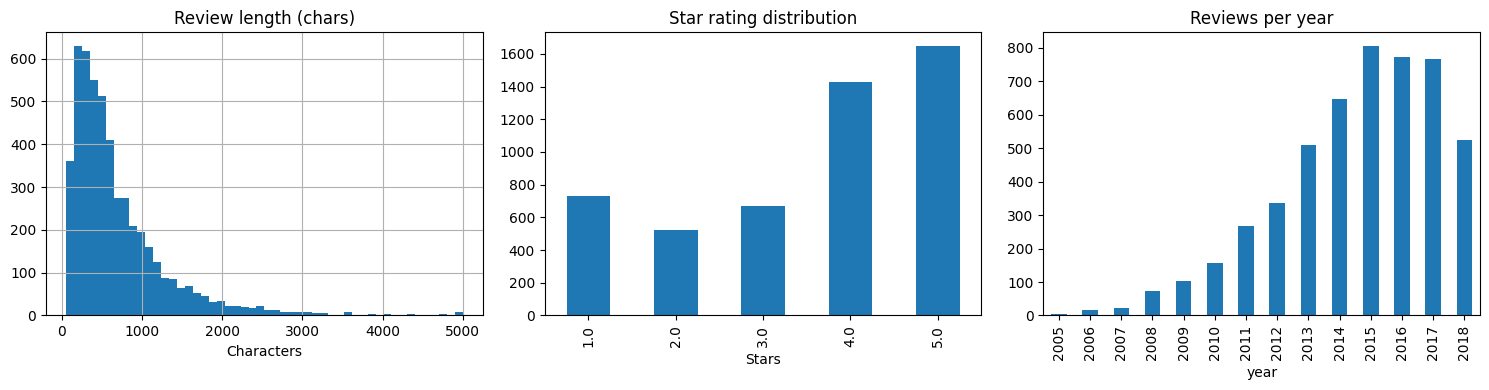

=== Summary ===
Text length  — median: 514  mean: 704  p95: 1917
Unique businesses: 259
Date range: 2005-05-15 → 2018-10-04

Star distribution:
stars
1.0     733
2.0     525
3.0     668
4.0    1425
5.0    1649

Sample hotel reviews:
[5.0★] Beautiful, tasteful and quaint. This b&b is paradise. The staff is friendly, the rooms are great and the entire experience is first class. If you want to experience some history and elegance this is a

[3.0★] We stayed here for 2 nights and booked it through Travelzoo for a better rate. Overall, the stay itself was alright - the hotel was in the center of everything in Philly, and the room was clean (for t

[4.0★] Such a beautiful place and the staff is very friendly. I cannot wait to go back. My room was comfy and right by the pool and both of my spa appointments went perfectly.



In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(reviews)
df['text_len'] = df['text'].str.len()
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Text length
df['text_len'].hist(bins=50, ax=axes[0])
axes[0].set_title('Review length (chars)')
axes[0].set_xlabel('Characters')

# Star distribution
df['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Star rating distribution')
axes[1].set_xlabel('Stars')

# Year
df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[2])
axes[2].set_title('Reviews per year')

plt.tight_layout()
plt.show()

print('=== Summary ===')
print(f"Text length  — median: {df['text_len'].median():.0f}  mean: {df['text_len'].mean():.0f}  p95: {df['text_len'].quantile(0.95):.0f}")
print(f"Unique businesses: {df['business_id'].nunique()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print()
print('Star distribution:')
print(df['stars'].value_counts().sort_index().to_string())
print()
print('Sample hotel reviews:')
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"[{row['stars']}★] {row['text'][:200]}")
    print()